Install Required Libraries

In [1]:
pip install pandas mysql-connector-python matplotlib openai

Note: you may need to restart the kernel to use updated packages.


Connect to MySQL Database

In [2]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
from openai import OpenAI

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hr_dashboard"
)

query = """
SELECT 
    e.employee_id,
    e.department,
    e.joining_date,
    r.resignation_date,
    r.reason
FROM employee e
LEFT JOIN resignation r
ON e.employee_id = r.employee_id
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\panka\AppData\Local\Temp\ipykernel_22912\2312946256.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_id,department,joining_date,resignation_date,reason
0,101,IT,2021-01-10,2024-03-01,Better Salary
1,103,IT,2020-06-20,2024-02-15,Work Life Balance
2,104,Sales,2021-09-05,2024-01-10,Career Growth
3,105,Sales,2022-01-15,2024-04-01,Relocation
4,102,HR,2022-03-15,None,None


Calculate Attrition Rate

Total Employees per Department

In [4]:
total_employees = df.groupby("department")["employee_id"].count()

Employees Who Resigned

In [5]:
resigned = df[df["resignation_date"].notnull()]
resigned_by_dept = resigned.groupby("department")["employee_id"].count()

Attrition Rate Calculation

In [6]:
attrition_rate = (resigned_by_dept / total_employees) * 100
attrition_rate = attrition_rate.fillna(0)
print(attrition_rate)

department
Finance      0.000000
HR           0.000000
IT          66.666667
Sales      100.000000
Name: employee_id, dtype: float64


Analyze Reason for Leaving

In [7]:
reason_counts = resigned["reason"].value_counts()
print(reason_counts)

reason
Better Salary        1
Work Life Balance    1
Career Growth        1
Relocation           1
Name: count, dtype: int64


Attrition Rate by Department

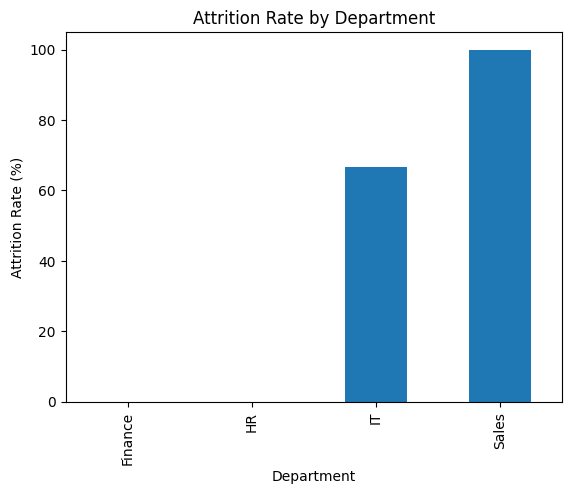

In [8]:
attrition_rate.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

Reasons for Leaving

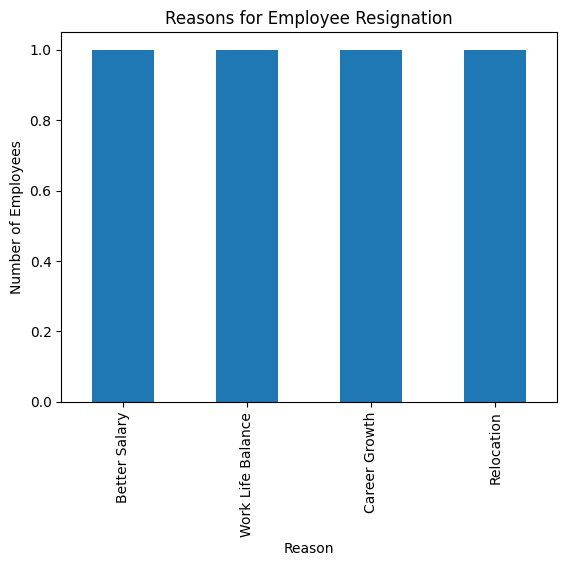

In [9]:
reason_counts.plot(kind="bar")

plt.title("Reasons for Employee Resignation")
plt.xlabel("Reason")
plt.ylabel("Number of Employees")

plt.show()

LLM Insights with OpenAI

In [10]:
client = OpenAI()

data_summary = attrition_rate.to_string()

response = client.responses.create(
    model="gpt-4.1-mini",
    input=f"""
Analyze employee attrition data by department and suggest HR improvements:

{data_summary}
"""
)

print(response.output_text)

The attrition rates by department are:

- Finance: 0%
- HR: 0%
- IT: 66.67%
- Sales: 100%

**Analysis:**

1. **Sales (100% attrition):**  
   This is an extremely high attrition rate, indicating every employee has left or is leaving. This could be due to high pressure, unrealistic targets, poor management, lack of career development, or compensation issues.

2. **IT (66.67% attrition):**  
   Also very high, suggesting many employees are dissatisfied or opportunities elsewhere are more attractive. Possible issues include work-life balance, project management, outdated technology stacks, or skill mismatch.

3. **Finance and HR (0% attrition):**  
   No attrition, which might indicate good employee satisfaction or possibly stagnation if no one is moving on.

---

**HR Improvement Suggestions:**

1. **Conduct Exit Interviews in Sales and IT:**  
   Understand the root causes behind the high attrition – workload, management style, opportunities for advancement, compensation, or work enviro